In [1]:
import warnings
from pathlib import Path
import json
import lingam
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pywt
from scipy.signal import butter, sosfiltfilt, welch
from sklearn.preprocessing import StandardScaler
from statsmodels.regression.linear_model import yule_walker
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = Path("../../data")
EPN_DIR = DATA_DIR / "epn612" / "raw"

FS = 200  # Hz, Myo armband sampling rate
GESTURES = ["noGesture", "open", "pinch", "waveOut", "fist", "waveIn"]
N_CHANNELS = 8
AR_ORDER = 4

FOURIER_SEG_SECONDS = 2.0  # Welch nperseg, same convention as plot_open_fist_examples.ipynb

CWT_WAVELET = "cmor1.5-1.0"  # complex Morlet, bandwidth=1.5, center freq=1.0
CWT_FREQS = np.geomspace(2.0, 99.0, 16)  # Hz, capped just under the 100 Hz Nyquist
CWT_SCALES = pywt.frequency2scale(CWT_WAVELET, CWT_FREQS / FS)

DRIFT_CUTOFF_HZ = 20.0
_highpass_sos = butter(4, DRIFT_CUTOFF_HZ, btype="highpass", fs=FS, output="sos")


def apply_highpass(x: np.ndarray) -> np.ndarray:
    """Zero-phase Butterworth high-pass (removes DC offset and sub-20Hz drift)."""
    return sosfiltfilt(_highpass_sos, x, axis=-1)

## Load shared causal-discovery output

Data loading + GFCI now live once in `../causal_discovery/EMG_causal_discovery.ipynb`
(prevents duplicating that expensive, JVM-based step per environment
grouping -- also sidesteps the "JVM cannot be restarted" crash that hit
whenever this cell got re-run in an existing kernel). This just loads its
saved `wide_df` and GFCI-selected `FEATURE_COLS_ICP`.

In [2]:
import json
import pickle
from pathlib import Path

SHARED_CAUSAL_DISCOVERY_DIR = Path("../causal_discovery/output")

with open(SHARED_CAUSAL_DISCOVERY_DIR / "wide_df.pkl", "rb") as f:
    wide_df = pickle.load(f)

with open(SHARED_CAUSAL_DISCOVERY_DIR / "feature_cols_icp.json") as f:
    FEATURE_COLS_ICP = json.load(f)

with open(SHARED_CAUSAL_DISCOVERY_DIR / "feature_cols_wide.json") as f:
    FEATURE_COLS_WIDE = json.load(f)

print(f"Loaded from shared causal-discovery output: wide_df {wide_df.shape}, "
      f"{len(FEATURE_COLS_ICP)} GFCI-selected candidate features for ICP")
print(FEATURE_COLS_ICP)

Loaded from shared causal-discovery output: wide_df (5508, 33), 9 GFCI-selected candidate features for ICP
['ch1_mav', 'ch8_mav', 'ch7_mav', 'ch4_mav', 'ch2_mav', 'ch5_mav', 'ch5_fft_mean_freq', 'ch6_mav', 'ch3_mav']


In [3]:
display(wide_df)

,user,gesture,age,gender,is_female,distanceFromElbowToMyoInCm,distanceFromElbowToUlnaInCm,armPerimeterInCm,recording_date,ch1_mav,...,ch5_fft_mean_freq,ch6_mav,ch6_fft_peak_freq,ch6_fft_mean_freq,ch7_mav,ch7_fft_peak_freq,ch7_fft_mean_freq,ch8_mav,ch8_fft_peak_freq,ch8_fft_mean_freq
0,user1,noGesture,19,man,0.0,6.0,24.0,23.0,2019-10-30 14:34:28,0.895392,...,62.722870,0.957900,88.0,62.268805,0.743140,91.5,60.436754,0.764259,88.5,60.697561
1,user1,noGesture,19,man,0.0,6.0,24.0,23.0,2019-10-30 14:34:28,0.936866,...,64.008650,0.968333,73.0,60.045452,0.791993,88.0,61.995388,0.768542,82.0,61.913615
2,user1,noGesture,19,man,0.0,6.0,24.0,23.0,2019-10-30 14:34:28,1.100648,...,60.165651,0.998615,29.5,62.335222,0.795677,76.5,59.992599,0.844713,90.0,62.737565
3,user1,open,19,man,0.0,6.0,24.0,23.0,2019-10-30 14:34:28,2.536149,...,62.790041,1.933941,65.5,61.215896,1.967835,66.5,60.764028,3.952365,68.5,67.371262
4,user1,open,19,man,0.0,6.0,24.0,23.0,2019-10-30 14:34:28,2.110451,...,64.941584,1.947802,87.0,69.948563,1.773373,83.0,69.633400,2.652607,67.0,60.070690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5503,user306,fist,22,woman,1.0,10.0,24.0,21.0,2019-09-17 11:18:07,4.811018,...,59.733557,4.530748,40.5,60.098866,3.093228,71.5,63.918793,3.788100,69.5,66.370881
5504,user306,fist,22,woman,1.0,10.0,24.0,21.0,2019-09-17 11:18:07,5.019664,...,58.084498,4.311823,69.0,59.359940,5.245919,91.5,64.249806,5.792261,73.0,66.935525
5505,user306,waveIn,22,woman,1.0,10.0,24.0,21.0,2019-09-17 11:18:07,2.776250,...,56.623241,1.884345,38.5,55.125340,3.057155,87.0,67.310956,3.724980,87.0,71.985710
5506,user306,waveIn,22,woman,1.0,10.0,24.0,21.0,2019-09-17 11:18:07,3.050146,...,51.978964,2.765701,36.5,55.799665,3.574213,93.5,65.548866,3.261252,95.0,73.851165


In [4]:
subset_df = wide_df[wide_df['user']=='user2']
display(subset_df)

,user,gesture,age,gender,is_female,distanceFromElbowToMyoInCm,distanceFromElbowToUlnaInCm,armPerimeterInCm,recording_date,ch1_mav,...,ch5_fft_mean_freq,ch6_mav,ch6_fft_peak_freq,ch6_fft_mean_freq,ch7_mav,ch7_fft_peak_freq,ch7_fft_mean_freq,ch8_mav,ch8_fft_peak_freq,ch8_fft_mean_freq
18,user2,noGesture,24,man,0.0,10.0,29.0,29.0,2019-10-23 20:50:33,0.679192,...,63.414605,0.679490,40.0,59.281240,0.696418,70.5,60.521431,0.689782,87.5,61.161283
19,user2,noGesture,24,man,0.0,10.0,29.0,29.0,2019-10-23 20:50:33,1.860699,...,62.104539,0.791739,34.5,56.973642,1.362574,85.5,67.346887,4.058805,71.5,68.405687
20,user2,noGesture,24,man,0.0,10.0,29.0,29.0,2019-10-23 20:50:33,0.994446,...,62.400165,0.716735,68.0,58.042747,0.917525,73.5,64.982413,1.631153,71.0,64.301887
21,user2,open,24,man,0.0,10.0,29.0,29.0,2019-10-23 20:50:33,2.698234,...,69.105757,1.216858,68.5,68.033913,1.800614,93.0,66.773153,7.075151,83.5,68.447228
22,user2,open,24,man,0.0,10.0,29.0,29.0,2019-10-23 20:50:33,3.625812,...,61.987561,1.247698,93.0,63.410168,2.344345,43.0,65.111578,13.848632,85.5,69.270461
23,user2,open,24,man,0.0,10.0,29.0,29.0,2019-10-23 20:50:33,3.075318,...,69.844356,1.241138,81.5,66.215144,2.731142,88.5,70.298487,10.671352,88.5,66.429825
24,user2,pinch,24,man,0.0,10.0,29.0,29.0,2019-10-23 20:50:33,2.661617,...,66.715273,1.148855,37.0,60.808331,3.072643,79.0,65.813741,10.048001,90.0,66.684764
25,user2,pinch,24,man,0.0,10.0,29.0,29.0,2019-10-23 20:50:33,2.869534,...,65.025565,1.333175,75.5,58.688759,2.718182,42.0,53.778857,5.551348,70.0,65.472850
26,user2,pinch,24,man,0.0,10.0,29.0,29.0,2019-10-23 20:50:33,2.792609,...,68.741927,1.144079,40.5,58.904854,3.369333,67.5,60.725539,6.641624,90.0,70.871470
27,user2,waveOut,24,man,0.0,10.0,29.0,29.0,2019-10-23 20:50:33,2.945098,...,67.502004,2.252091,86.0,70.017318,2.258355,91.0,65.616459,6.535300,77.5,65.306844


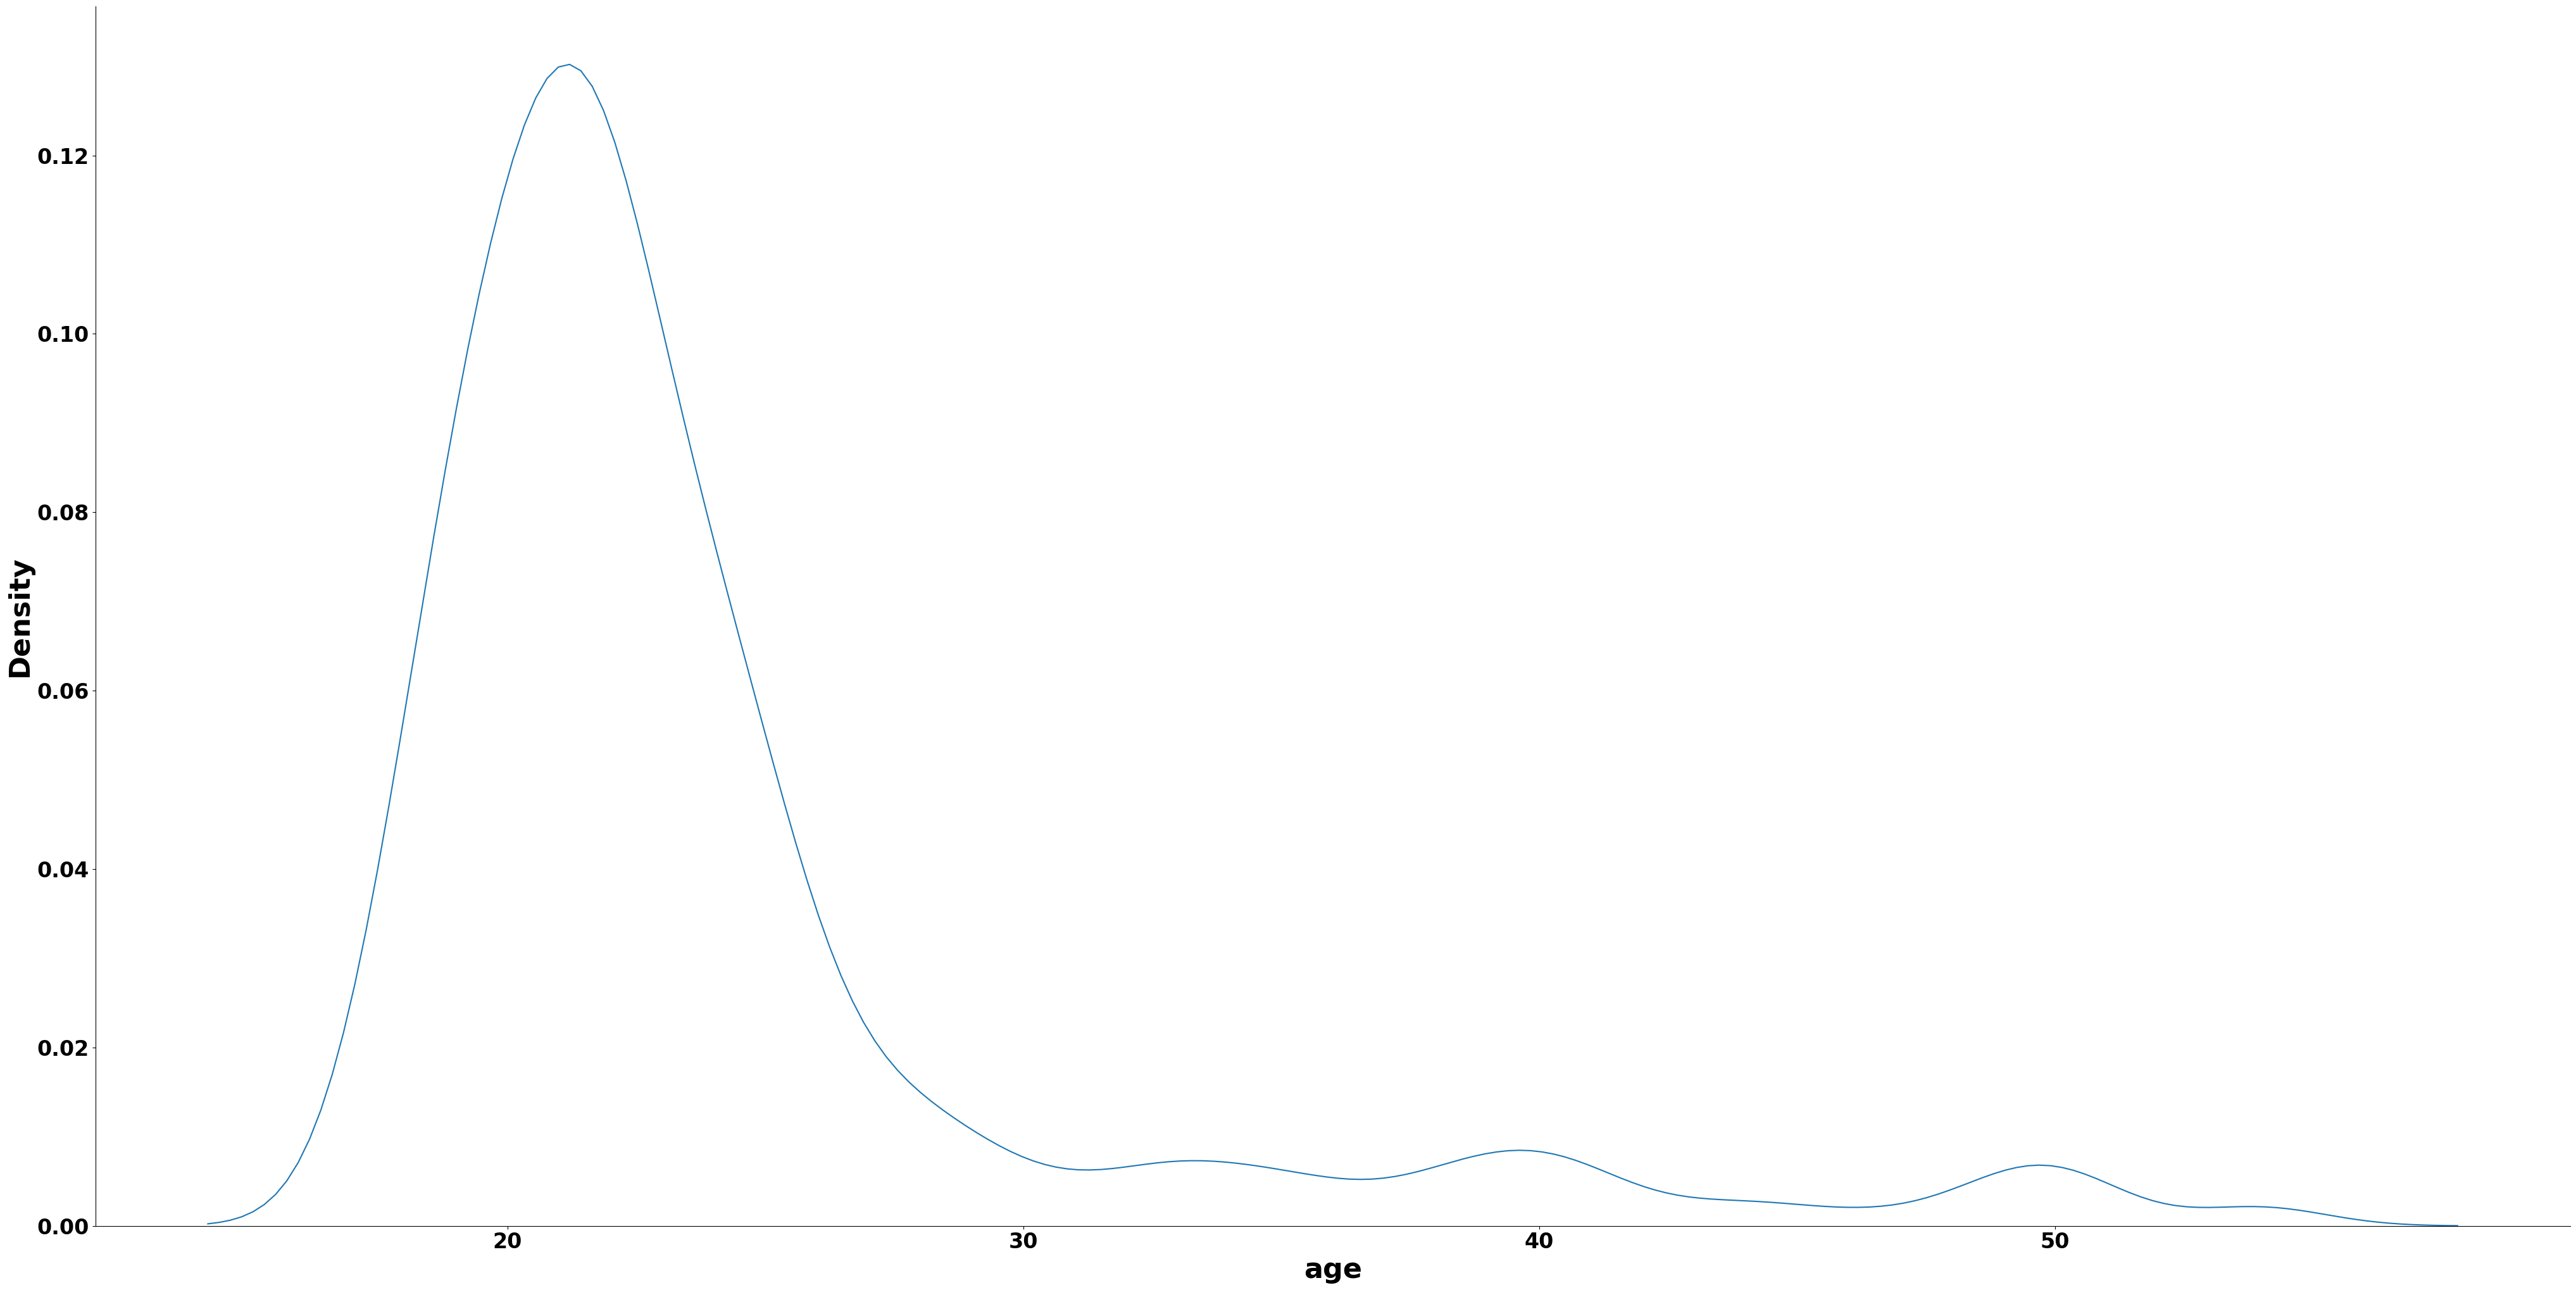

In [5]:

g = sns.displot(wide_df, x="age", kind="kde", height=20, aspect=2.0)
g.set_axis_labels("age", "Density", fontsize=32, fontweight="bold")
g.ax.tick_params(labelsize=24)
g.ax.set_title(g.ax.get_title(), fontsize=32, fontweight="bold")
for label in g.ax.get_xticklabels() + g.ax.get_yticklabels():
    label.set_fontweight("bold")


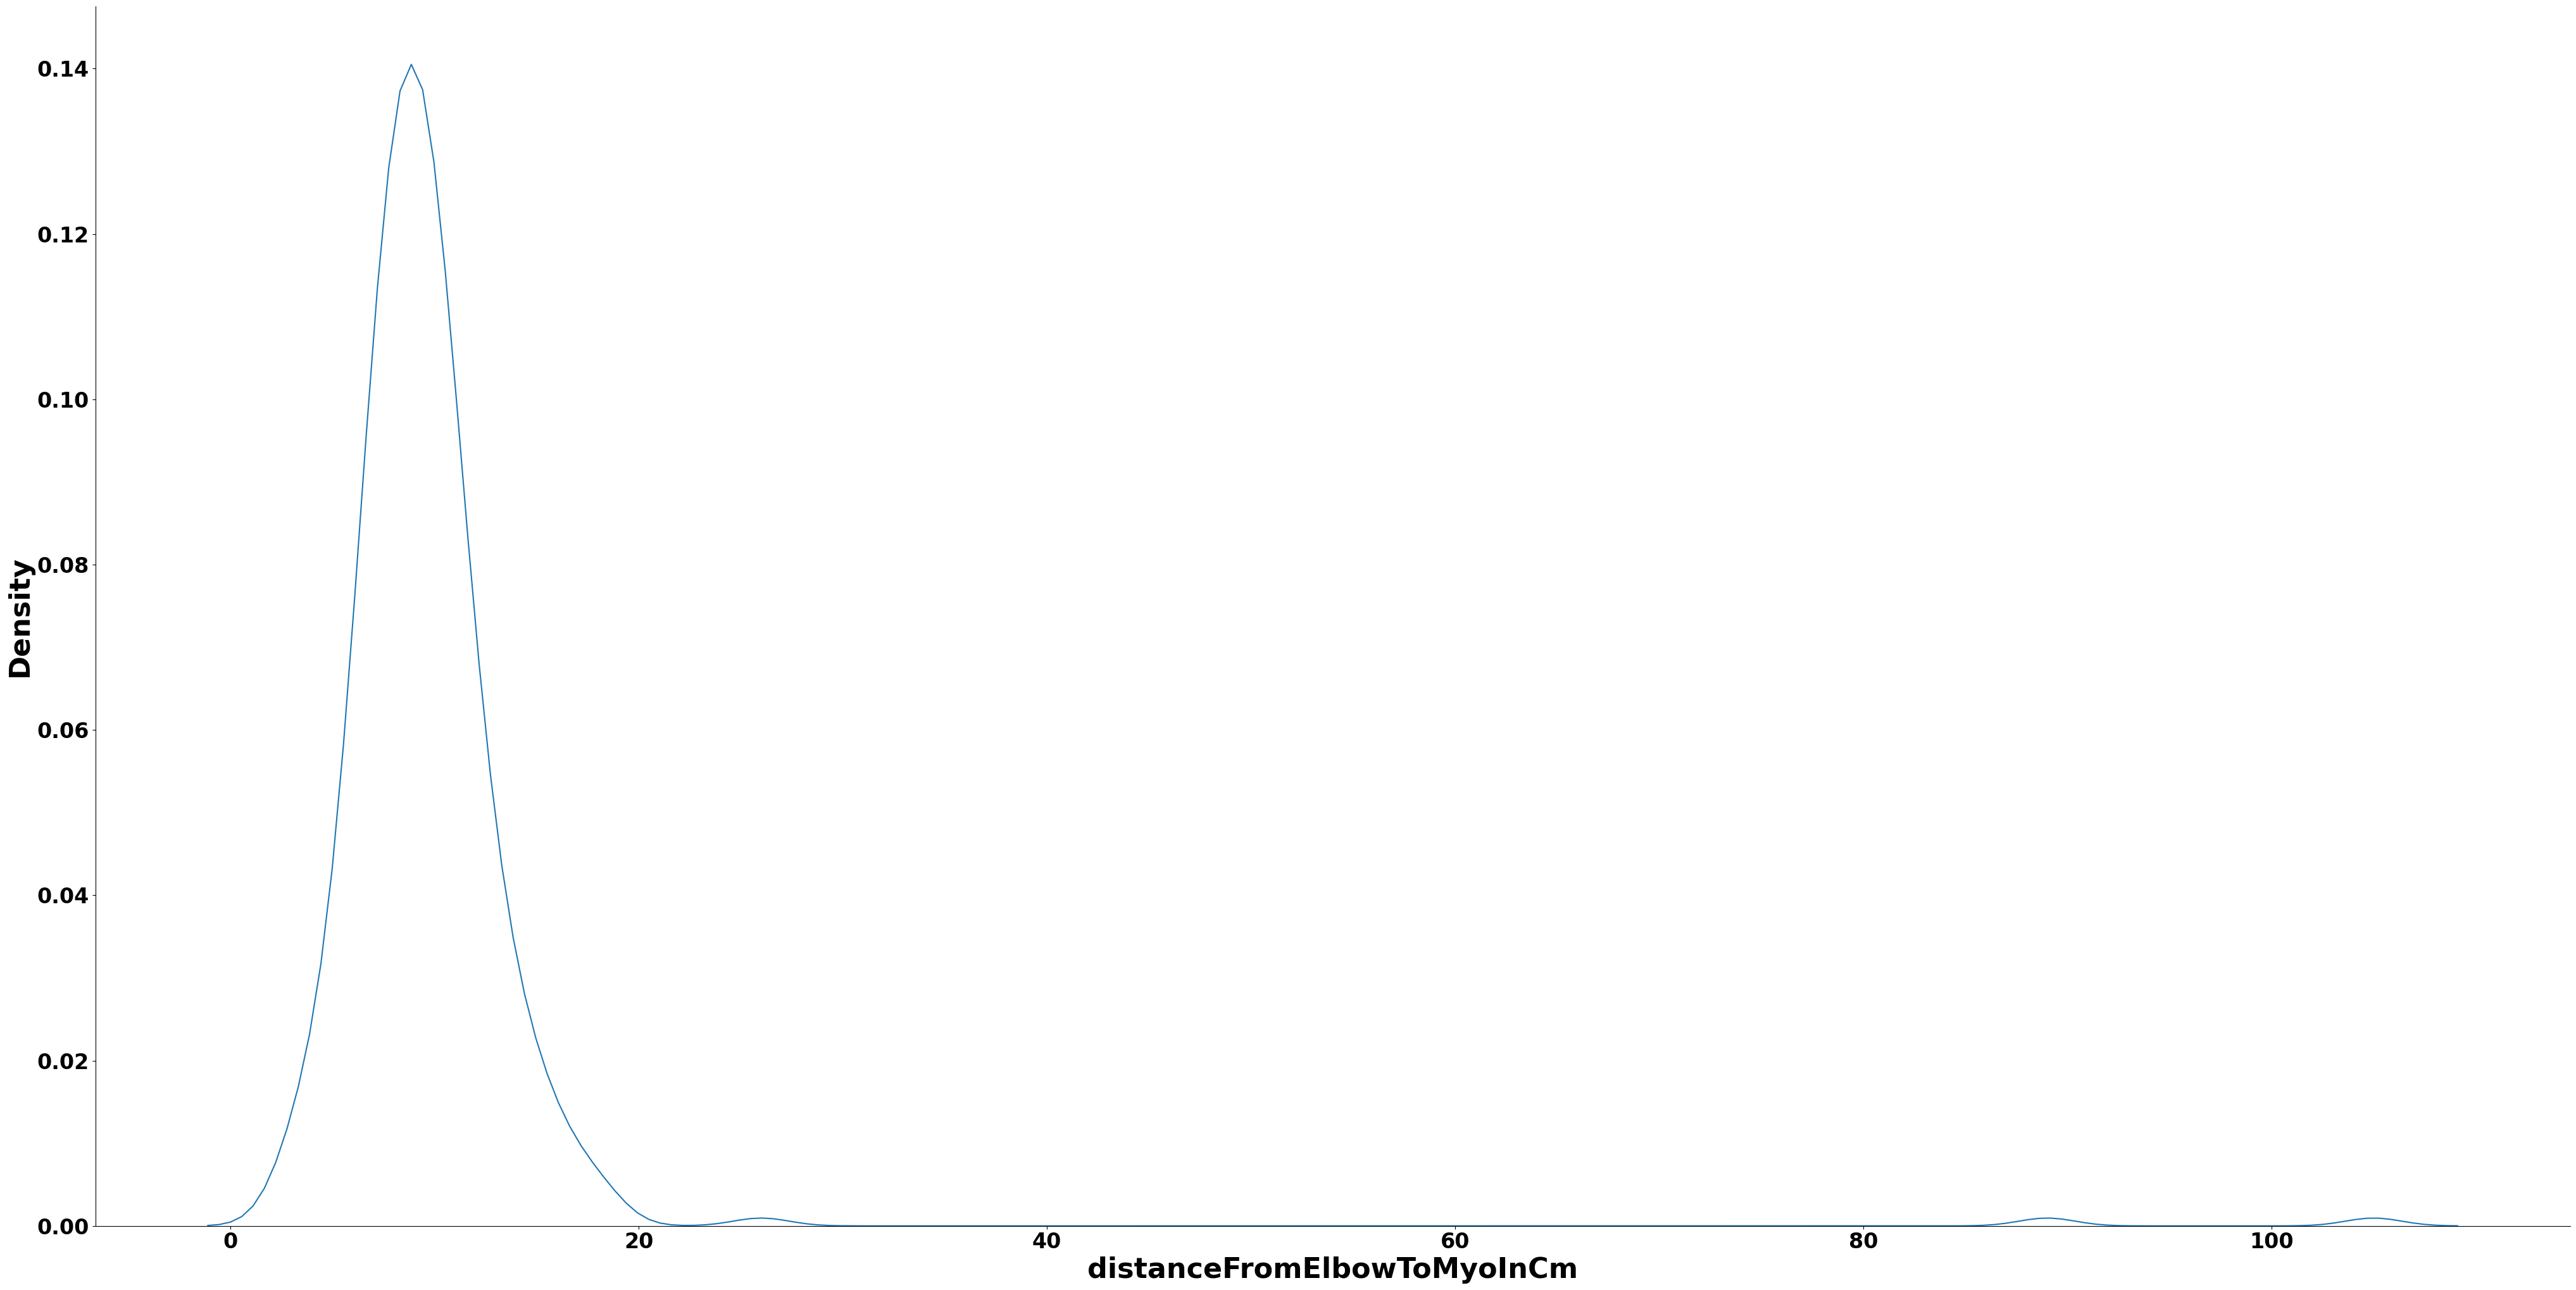

In [6]:
g = sns.displot(wide_df, x="distanceFromElbowToMyoInCm", kind="kde", height=20, aspect=2.0)
g.set_axis_labels("distanceFromElbowToMyoInCm", "Density", fontsize=32, fontweight="bold")
g.ax.tick_params(labelsize=24)
g.ax.set_title(g.ax.get_title(), fontsize=32, fontweight="bold")
for label in g.ax.get_xticklabels() + g.ax.get_yticklabels():
    label.set_fontweight("bold")

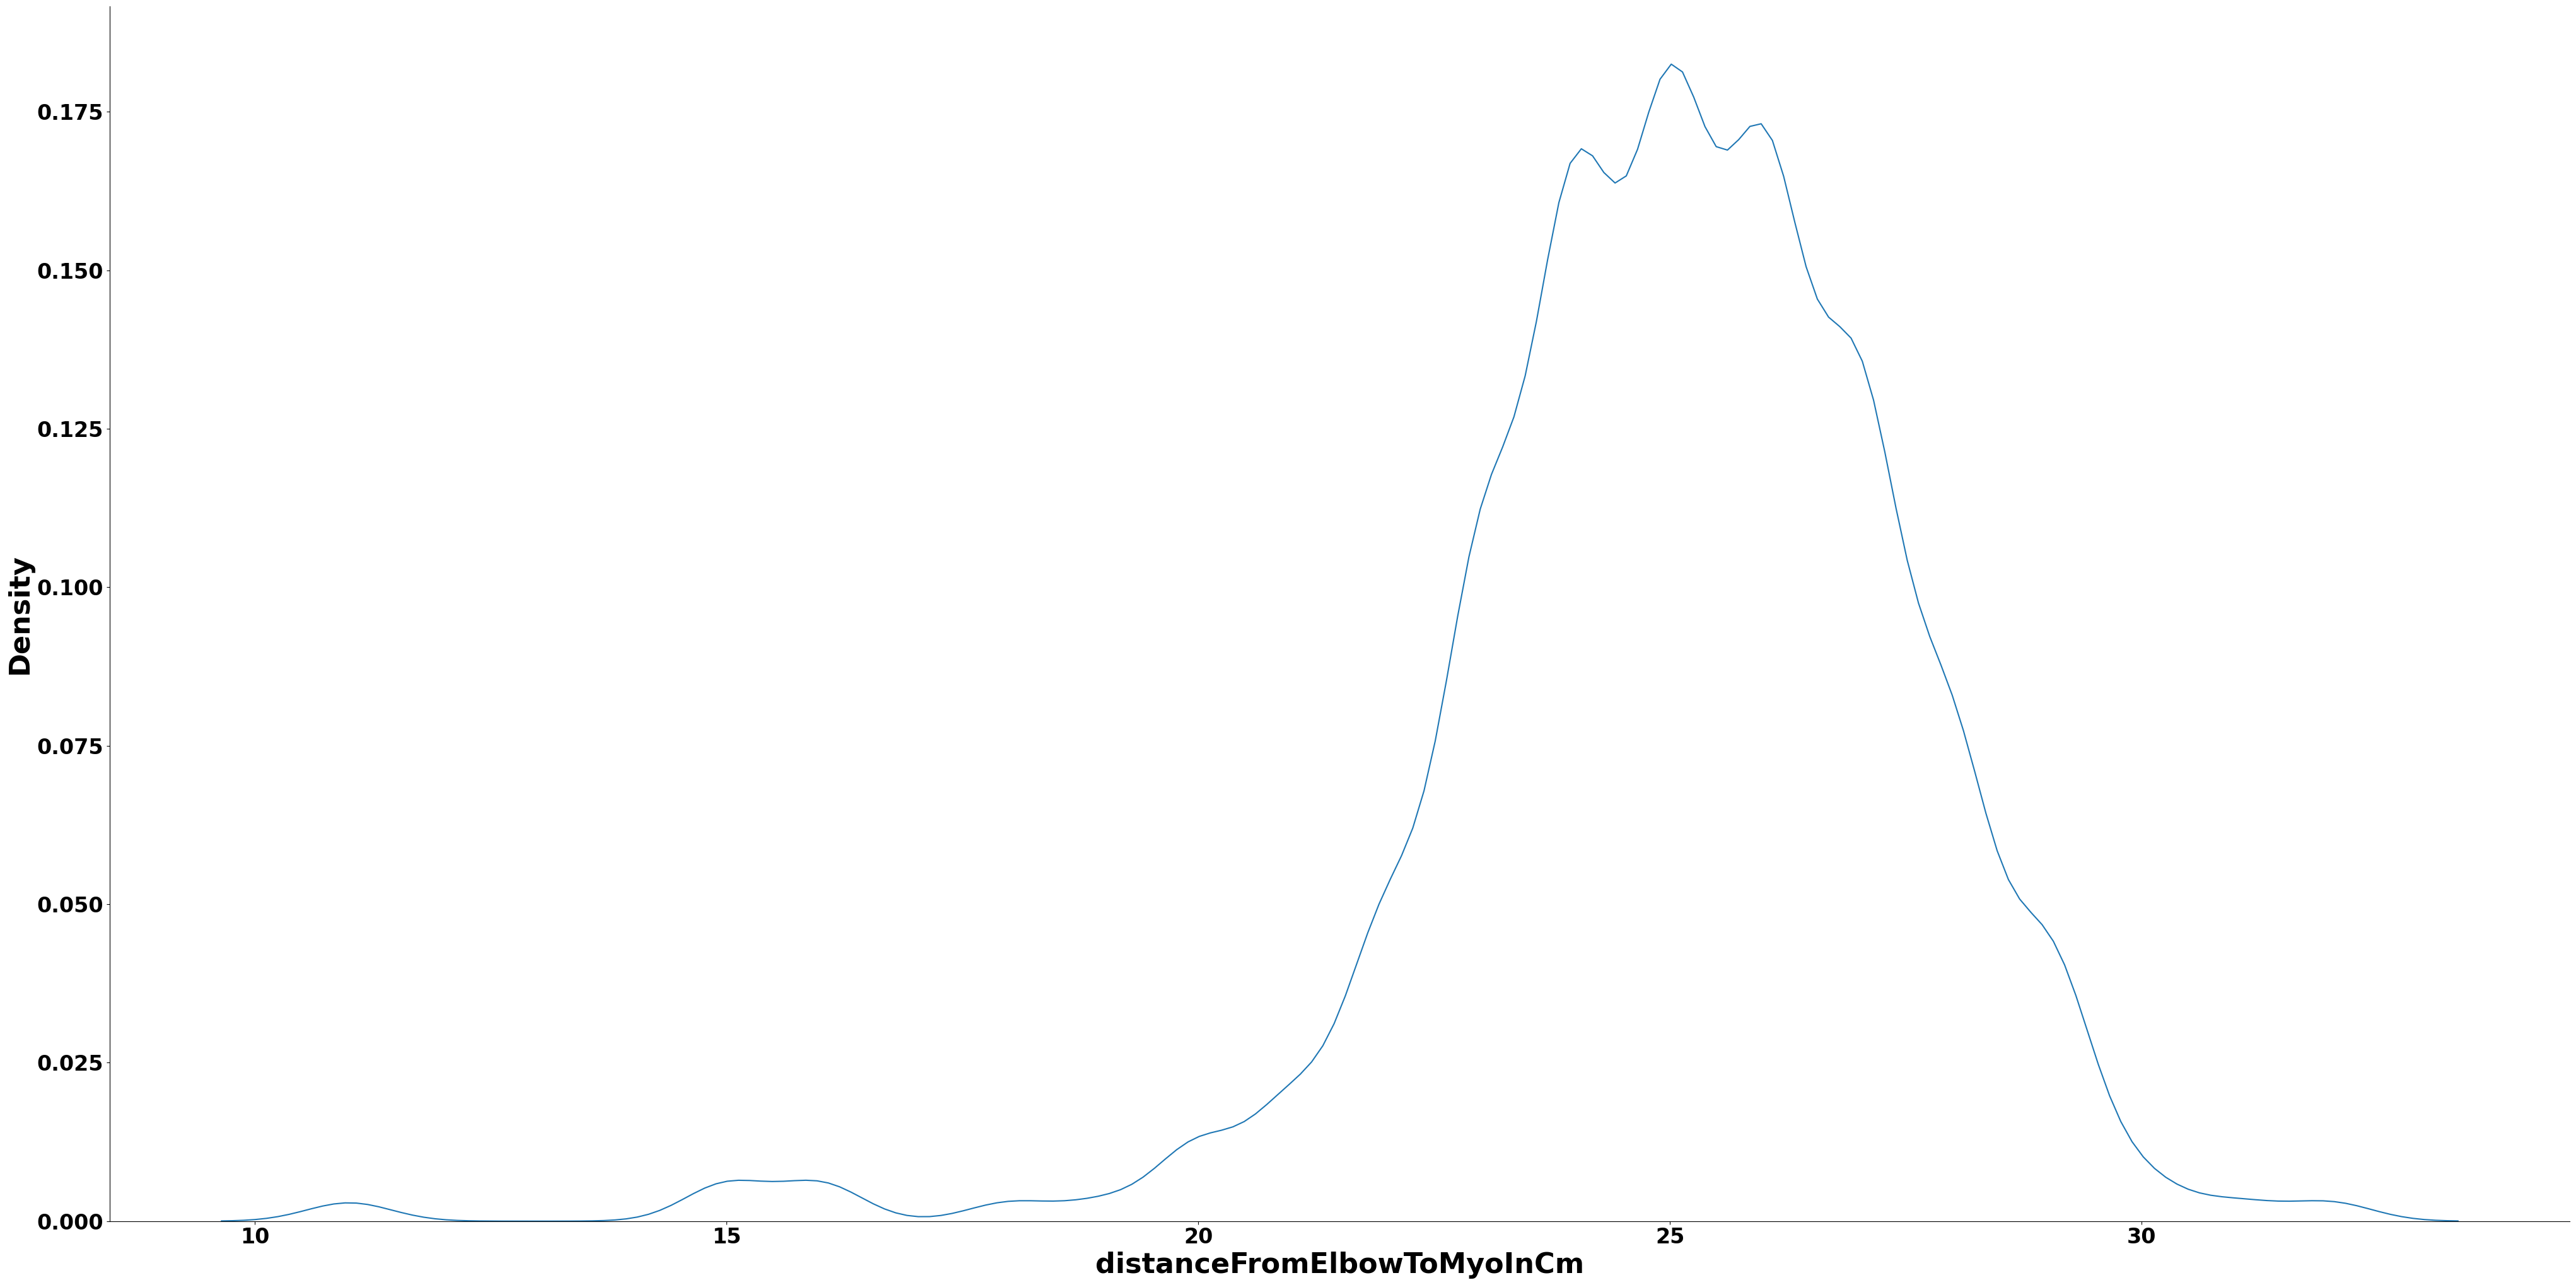

In [7]:
g = sns.displot(wide_df, x="distanceFromElbowToUlnaInCm", kind="kde", height=20, aspect=2.0)
g.set_axis_labels("distanceFromElbowToMyoInCm", "Density", fontsize=32, fontweight="bold")
g.ax.tick_params(labelsize=24)
g.ax.set_title(g.ax.get_title(), fontsize=32, fontweight="bold")
for label in g.ax.get_xticklabels() + g.ax.get_yticklabels():
    label.set_fontweight("bold")

## Invariant Causal Prediction (ICP) across forearm-length groups

In [8]:
def ulna_distance_group(dist: int) -> str:
    if dist < 22:
        return "10-22"
    elif dist < 27:
        return "22-27"
    else:
        return "27+"


DIST_GROUPS_ORDER = ["10-22", "22-27", "27+"]

wide_df["dist_group"] = wide_df["distanceFromElbowToUlnaInCm"].apply(ulna_distance_group)

print("users per dist group:")
print(wide_df.drop_duplicates("user").groupby("dist_group")["user"].nunique().reindex(DIST_GROUPS_ORDER))
print()
print("windows per dist group:")
print(wide_df.groupby("dist_group").size().reindex(DIST_GROUPS_ORDER))


users per dist group:
dist_group
10-22     17
22-27    208
27+       81
Name: user, dtype: int64

windows per dist group:
dist_group
10-22     306
22-27    3744
27+      1458
dtype: int64


In [9]:
ICP_MAX_PER_ENV = 200
ICP_SEED = 0


def subsample_for_icp(seed: int = ICP_SEED, max_per_env: int = ICP_MAX_PER_ENV) -> pd.DataFrame:
    """Up to max_per_env rows per age group (fewer if an age group has less
    data than that), sampled once and reused across all 6 gestures below so
    every gesture's ICP fit sees the same rows."""
    parts = []
    for g in DIST_GROUPS_ORDER:
        sub = wide_df[wide_df["dist_group"] == g]
        n = min(len(sub), max_per_env)
        parts.append(sub.sample(n=n, random_state=seed))
    return pd.concat(parts).reset_index(drop=True)


wide_df_icp = subsample_for_icp()
print("rows per age group used for ICP (capped at", ICP_MAX_PER_ENV, "):")
print(wide_df_icp.groupby("dist_group").size().reindex(DIST_GROUPS_ORDER))

rows per age group used for ICP (capped at 200 ):
dist_group
10-22    200
22-27    200
27+      200
dtype: int64


In [10]:
import itertools
import time

## Classification ICP: deviance residuals and ICP
Why not ANOVA:
Check if predictive power diminishes across groups between feature and target variable

In [11]:
from sklearn.linear_model import LogisticRegression
import scipy.stats

DEV_ICP_ALPHA = 0.05

ACTIVE_GESTURES = [g for g in GESTURES if g != "noGesture"]  # noGesture excluded, same convention as GFCI


def _deviance_residuals(X, y):
    """Unregularized (penalty=None) sklearn logistic fit -> per-row deviance
    residuals. For the empty feature set there's nothing to fit a model to,
    so `mu` is just the overall base rate of y."""
    if X.shape[1] == 0:
        mu = np.full(len(y), y.mean())
    else:
        clf = LogisticRegression(penalty=None, solver="lbfgs", max_iter=100)
        clf.fit(X, y)
        mu = clf.predict_proba(X)[:, 1]
    mu = np.clip(mu, 1e-12, 1 - 1e-12)
    return np.sign(y - mu) * np.sqrt(-2 * (y * np.log(mu) + (1 - y) * np.log(1 - mu)))


def _test_hypothesis_deviance(X, y, S, env_labels, envs_order):
    """causalicp's own t-test-on-mean + F-test-on-variance combination
    (smallest p-value, Bonferroni-corrected by 2*(e-1)), applied to deviance
    residuals from a pooled logistic fit instead of raw residuals from a
    pooled OLS fit."""
    Xs = X[:, S] if len(S) > 0 else np.zeros((len(y), 0))
    dev_resid = _deviance_residuals(Xs, y)

    e = len(envs_order)
    mean_pvalues = np.zeros(e)
    var_pvalues = np.zeros(e)
    for i, g in enumerate(envs_order):
        r_i = dev_resid[env_labels == g]
        r_others = np.hstack([dev_resid[env_labels == g2] for g2 in envs_order if g2 != g])
        mean_pvalues[i] = scipy.stats.ttest_ind(r_i, r_others, equal_var=False).pvalue
        F = np.var(r_i, ddof=1) / np.var(r_others, ddof=1)
        p = scipy.stats.f.cdf(F, len(r_i) - 1, len(r_others) - 1)
        var_pvalues[i] = 2 * min(p, 1 - p)

    smallest_pvalue = min(mean_pvalues.min(), var_pvalues.min())
    return min(1.0, smallest_pvalue * 2 * (e - 1))


def gesture_dist_deviance_icp(gesture: str, alpha: float = DEV_ICP_ALPHA):
    X = StandardScaler().fit_transform(wide_df_icp[FEATURE_COLS_ICP].values)
    y = (wide_df_icp["gesture"] == gesture).astype(float).values
    env_labels = wide_df_icp["dist_group"].values

    p = X.shape[1]
    accepted, rejected = [], []
    p_values = {}
    estimate = set(range(p))

    # Full power set: 2**p subsets. With FEATURE_COLS_ICP now capped at the
    # top 9 features by GFCI edge strength, that's 512 subsets -- back to the
    # original tractable scale, so every combination is tested exhaustively
    # (no subset-size cap needed).
    for size in range(p + 1):
        for combo in itertools.combinations(range(p), size):
            S = list(combo)
            p_value = _test_hypothesis_deviance(X, y, S, env_labels, DIST_GROUPS_ORDER)
            p_values[tuple(S)] = p_value
            if p_value > alpha:
                accepted.append(set(S))
                estimate &= set(S)
            else:
                rejected.append(set(S))

    if len(accepted) == 0:
        estimate = None
    return {"estimate": estimate, "accepted_sets": accepted, "rejected_sets": rejected, "p_values": p_values}


print(f"Testing the full power set of {len(FEATURE_COLS_ICP)} features: "
      f"{2**len(FEATURE_COLS_ICP)} subsets")

dist_deviance_icp_results = {}
for gesture in ACTIVE_GESTURES:
    dist_deviance_icp_results[gesture] = gesture_dist_deviance_icp(gesture)


for gesture, result in dist_deviance_icp_results.items():
    invariant = [] if result["estimate"] is None else [FEATURE_COLS_ICP[i] for i in sorted(result["estimate"])]
    n_accepted = len(result["accepted_sets"])
    n_tested = n_accepted + len(result["rejected_sets"])
    print(f"{gesture}: invariant estimate = {invariant or '(empty)'}  [{n_accepted}/{n_tested} subsets accepted]")


Testing the full power set of 9 features: 512 subsets


open: invariant estimate = (empty)  [512/512 subsets accepted]
pinch: invariant estimate = (empty)  [512/512 subsets accepted]
waveOut: invariant estimate = (empty)  [497/512 subsets accepted]
fist: invariant estimate = (empty)  [310/512 subsets accepted]
waveIn: invariant estimate = (empty)  [410/512 subsets accepted]


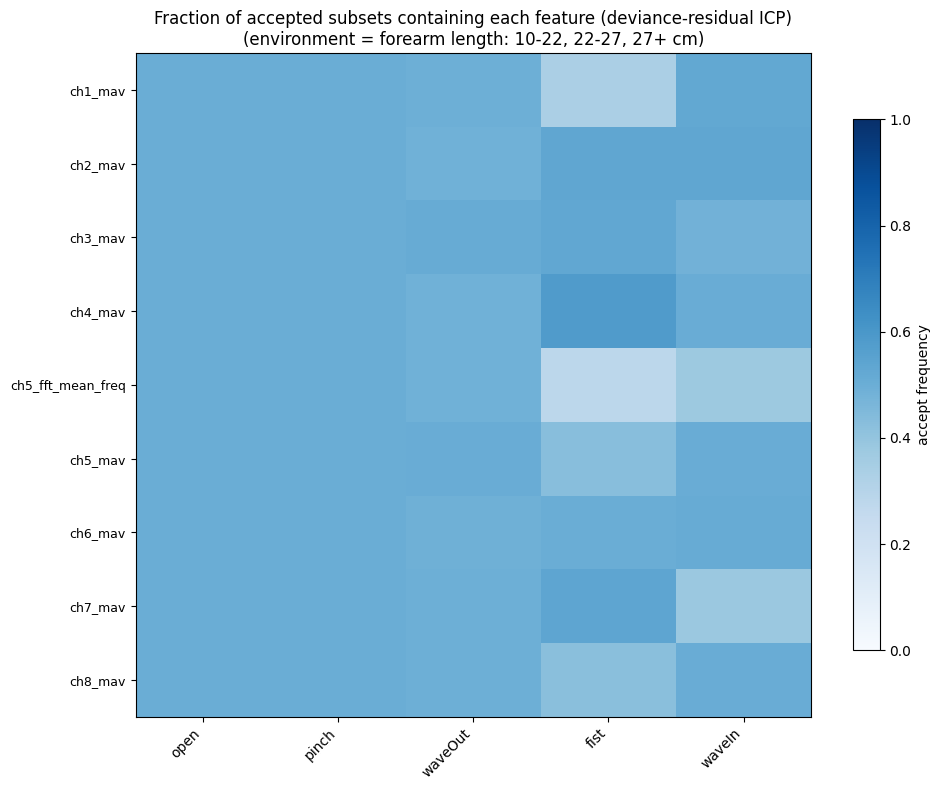

Mean accept-frequency across all 5 active gestures (deviance-residual ICP, noGesture excluded):
feature
ch4_mav              0.514574
ch2_mav              0.510263
ch3_mav              0.504117
ch6_mav              0.500786
ch5_mav              0.488276
ch8_mav              0.484083
ch7_mav              0.482833
ch1_mav              0.469921
ch5_fft_mean_freq    0.428233
dtype: float64


In [12]:
dist_dev_freq_rows = []
for gesture, result in dist_deviance_icp_results.items():
    n_accepted = len(result["accepted_sets"])
    for i, feature in enumerate(FEATURE_COLS_ICP):
        freq = sum(1 for s in result["accepted_sets"] if i in s) / n_accepted if n_accepted else np.nan
        dist_dev_freq_rows.append({"gesture": gesture, "feature": feature, "accept_freq": freq})

dist_dev_freq_matrix = pd.DataFrame(dist_dev_freq_rows).pivot(index="feature", columns="gesture", values="accept_freq")
dist_dev_freq_matrix = dist_dev_freq_matrix[ACTIVE_GESTURES]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(dist_dev_freq_matrix.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(dist_dev_freq_matrix.columns)), dist_dev_freq_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(dist_dev_freq_matrix.index)), dist_dev_freq_matrix.index, fontsize=9)
ax.set_title("Fraction of accepted subsets containing each feature (deviance-residual ICP)\n(environment = forearm length: 10-22, 22-27, 27+ cm)", fontsize=12)
fig.colorbar(im, ax=ax, label="accept frequency", shrink=0.8)
fig.tight_layout()
plt.show()

mean_dist_dev_accept_freq = dist_dev_freq_matrix.mean(axis=1).sort_values(ascending=False)
print("Mean accept-frequency across all 5 active gestures (deviance-residual ICP, noGesture excluded):")
print(mean_dist_dev_accept_freq)